<a href="https://colab.research.google.com/github/farrelrassya/PracticalLinearAlgebra/blob/main/02.Chapter2%3AVectors-part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 2: Vectors
## *Practical Linear Algebra for Data Science* — Mike X Cohen

Vectors are the atoms of linear algebra. Every matrix, every transformation, every machine-learning model ultimately reduces to operations on vectors. This notebook transforms the textbook's Chapter 2 into executable, richly-explained code that you can run cell by cell on Google Colab.

**What we will cover:**

1. Creating and visualizing vectors in NumPy (orientation, dimensionality, shape)
2. Vector arithmetic -- addition, subtraction, scalar multiplication
3. Broadcasting in Python
4. Vector magnitude, unit vectors, and norms
5. The dot product -- computation, geometry, and interpretation
6. Other vector multiplications -- Hadamard, outer product
7. Orthogonal vector decomposition -- projecting onto a reference vector

Each code cell is followed by a detailed explanation that connects outputs to theory, equations, and production insights.

## 0. Setup

We import the core scientific-Python stack. NumPy is the workhorse for all vector and matrix operations; Matplotlib handles visualization.

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Consistent styling for all plots
plt.rcParams.update({
    'figure.figsize': (7, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 12
})

print('NumPy version:', np.__version__)
print('Setup complete.')

NumPy version: 2.0.2
Setup complete.


Environment ready. All subsequent cells assume NumPy is imported as `np` and Matplotlib as `plt`.

## 1. Creating and Visualizing Vectors in NumPy

In linear algebra, a **vector** is an ordered list of numbers. Two key properties define a vector:

- **Dimensionality** -- the number of elements. A vector with $n$ elements lives in $\mathbb{R}^n$.
- **Orientation** -- column (tall and thin) or row (flat and wide).

Convention: lowercase bold letters denote vectors ($\mathbf{v}$), and we assume **column orientation** unless stated otherwise. A row vector is written $\mathbf{w}^T$, where the superscript $T$ indicates the **transpose** operation.

$$
\mathbf{x} = \begin{bmatrix} x_1 \\ x_2 \\ \vdots \\ x_n \end{bmatrix} \in \mathbb{R}^n
\qquad\text{(column vector)}
\qquad\qquad
\mathbf{x}^T = \begin{bmatrix} x_1 & x_2 & \cdots & x_n \end{bmatrix}
\qquad\text{(row vector)}
$$

### 1.1 Four Ways to Create a Vector in Python

In [20]:
# Four ways to create a vector
asList  = [1, 2, 3]                        # Python list
asArray = np.array([1, 2, 3])               # 1D NumPy array (orientationless)
rowVec  = np.array([[1, 2, 3]])             # 2D row vector
colVec  = np.array([[1], [2], [3]])         # 2D column vector

print(f'asList  type: {type(asList).__name__:10s}  shape: {np.shape(asList)}')
print(f'asArray type: {type(asArray).__name__:10s}  shape: {asArray.shape}')
print(f'rowVec  type: {type(rowVec).__name__:10s}  shape: {rowVec.shape}')
print(f'colVec  type: {type(colVec).__name__:10s}  shape: {colVec.shape}')

asList  type: list        shape: (3,)
asArray type: ndarray     shape: (3,)
rowVec  type: ndarray     shape: (1, 3)
colVec  type: ndarray     shape: (3, 1)


### Interpreting the Shapes

The output reveals a crucial terminological mismatch between mathematics and Python:

| Variable | Python shape | Math interpretation |
|----------|-------------|--------------------|
| `asList` | `(3,)` | 3-element orientationless list |
| `asArray` | `(3,)` | 3-element 1D array -- **no** row/column distinction |
| `rowVec` | `(1, 3)` | 1 row $\times$ 3 columns $\Rightarrow$ **row vector** |
| `colVec` | `(3, 1)` | 3 rows $\times$ 1 column $\Rightarrow$ **column vector** |

In mathematics, the **dimensionality** of a vector is the number of elements ($n = 3$ for all four). In Python/NumPy, **`ndim`** counts the number of *axes*: 1D arrays have `ndim=1`, while row and column vectors have `ndim=2`. The mathematical dimensionality is recovered via `shape`.

**Production insight:** Many subtle bugs arise from confusing 1D arrays `(n,)` with row vectors `(1, n)`. When writing production code, be explicit about shape. A quick `assert v.shape == (n, 1)` at function entry can save hours of debugging.

### 1.2 Geometry of Vectors

The **geometric interpretation** of a vector is a directed line segment with a specific **magnitude** (length) and **direction** (angle relative to an axis). A vector in **standard position** has its tail at the origin and its head at the concordant coordinate.

Below we plot the same vector $\mathbf{v} = [2, 3]^T$ starting from three different tail positions. All three arrows represent the *same* vector because they share the same magnitude and direction -- only the one starting at the origin is in standard position.

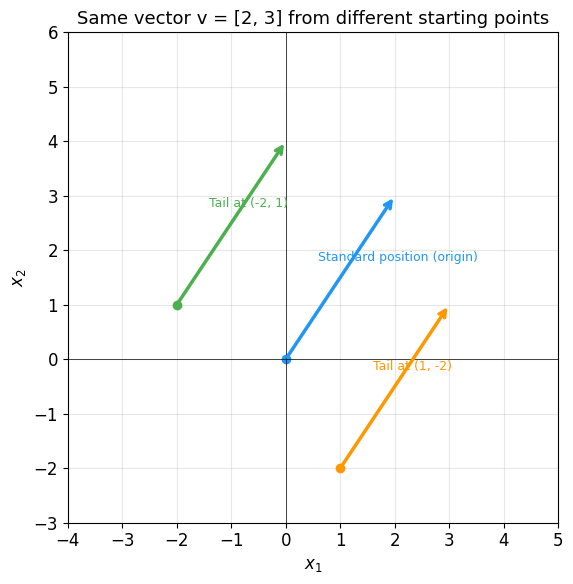

Figure saved.


In [21]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

v = np.array([2, 3])

# Same vector from three different starting points
tails = [(0, 0), (-2, 1), (1, -2)]
colors = ['#2196F3', '#4CAF50', '#FF9800']
labels = ['Standard position (origin)', 'Tail at (-2, 1)', 'Tail at (1, -2)']

for (tx, ty), c, lab in zip(tails, colors, labels):
    ax.annotate('', xy=(tx + v[0], ty + v[1]), xytext=(tx, ty),
                arrowprops=dict(arrowstyle='->', color=c, lw=2.5))
    ax.plot(tx, ty, 'o', color=c, ms=6)
    ax.text(tx + v[0]/2 - 0.4, ty + v[1]/2 + 0.3, lab, fontsize=9, color=c)

ax.set_xlim(-4, 5)
ax.set_ylim(-3, 6)
ax.set_aspect('equal')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(0, color='k', lw=0.5)
ax.set_title('Same vector v = [2, 3] from different starting points', fontsize=13)
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
plt.tight_layout()
plt.savefig('fig_vectors_same.png', dpi=100, bbox_inches='tight')
plt.show()
print('Figure saved.')

All three arrows have the same displacement $(\Delta x_1, \Delta x_2) = (2, 3)$, confirming that a vector encodes *direction and magnitude*, not absolute position. Only when the tail sits at the origin does the head coincide with the geometric coordinate $(2, 3)$.

**Why this matters:** In data science, we often think of vectors as feature lists (e.g., a row of a dataset). The geometric view becomes critical when we talk about similarity (dot products, cosine angles) and projections (regression, PCA). Both views -- algebraic *and* geometric -- are needed.

## 2. Vector Addition and Subtraction

Vector addition is element-wise: each component of one vector is added to the corresponding component of the other. Both vectors **must** share the same dimensionality *and* orientation.

$$
\mathbf{v} + \mathbf{w} =
\begin{bmatrix} v_1 \\ v_2 \\ v_3 \end{bmatrix}
+
\begin{bmatrix} w_1 \\ w_2 \\ w_3 \end{bmatrix}
=
\begin{bmatrix} v_1 + w_1 \\ v_2 + w_2 \\ v_3 + w_3 \end{bmatrix}
$$

In [22]:
v = np.array([4, 5, 6])
w = np.array([10, 20, 30])
u = np.array([0, 3, 6, 9])

vPlusW = v + w
print(f'v + w = {vPlusW}')

vMinusW = v - w
print(f'v - w = {vMinusW}')

# Dimension mismatch -- this will raise an error
try:
    uPlusW = u + w
except ValueError as e:
    print(f'\nu + w error: {e}')

v + w = [14 25 36]
v - w = [ -6 -15 -24]

u + w error: operands could not be broadcast together with shapes (4,) (3,) 


The results confirm element-wise arithmetic:

$$
\mathbf{v} + \mathbf{w} = [4 + 10,\; 5 + 20,\; 6 + 30] = [14,\; 25,\; 36]
$$
$$
\mathbf{v} - \mathbf{w} = [4 - 10,\; 5 - 20,\; 6 - 30] = [-6,\; -15,\; -24]
$$

Attempting to add $\mathbf{u} \in \mathbb{R}^4$ to $\mathbf{w} \in \mathbb{R}^3$ produces a `ValueError` because the shapes `(4,)` and `(3,)` are incompatible. This is the Python enforcement of the mathematical rule: vector addition is only defined for vectors of **equal dimensionality**.

**Cross-chapter connection:** Element-wise addition underpins gradient descent (Chapter 10+), where the parameter vector is updated as $\mathbf{w}_{t+1} = \mathbf{w}_t - \eta \nabla \mathcal{L}$. Every training step is just vector subtraction.

### 2.1 Why Orientation Matters: Row + Column = Broadcasting

In [23]:
v_row = np.array([[4, 5, 6]])       # shape (1, 3)
w_col = np.array([[10, 20, 30]]).T   # shape (3, 1)

result = v_row + w_col
print(f'v_row shape: {v_row.shape}')
print(f'w_col shape: {w_col.shape}')
print(f'Result shape: {result.shape}')
print(f'Result:\n{result}')

v_row shape: (1, 3)
w_col shape: (3, 1)
Result shape: (3, 3)
Result:
[[14 15 16]
 [24 25 26]
 [34 35 36]]


Adding a $(1, 3)$ row to a $(3, 1)$ column does **not** produce element-wise addition. Instead, NumPy **broadcasts**: it stretches the row vector down and the column vector across to form a full $(3, 3)$ matrix.

$$
\underbrace{\begin{bmatrix} 4 & 5 & 6 \end{bmatrix}}_{(1 \times 3)}
+
\underbrace{\begin{bmatrix} 10 \\ 20 \\ 30 \end{bmatrix}}_{(3 \times 1)}
=
\underbrace{\begin{bmatrix}
4+10 & 5+10 & 6+10 \\
4+20 & 5+20 & 6+20 \\
4+30 & 5+30 & 6+30
\end{bmatrix}}_{(3 \times 3)}
=
\begin{bmatrix}
14 & 15 & 16 \\
24 & 25 & 26 \\
34 & 35 & 36
\end{bmatrix}
$$

Each row of the result is the row vector plus one element of the column vector. This is broadcasting at work -- powerful and compact, but it can produce unexpected results if you accidentally mix orientations. The lesson: **two vectors should share both dimensionality and orientation for standard element-wise operations**.

### 2.2 Geometry of Vector Addition and Subtraction

**Addition (tail-to-head rule):** Place the tail of one vector at the head of the other. The sum vector goes from the first tail to the final head.

**Subtraction:** Place both vectors in standard position. The difference $\mathbf{v} - \mathbf{w}$ goes from the head of $\mathbf{w}$ to the head of $\mathbf{v}$.

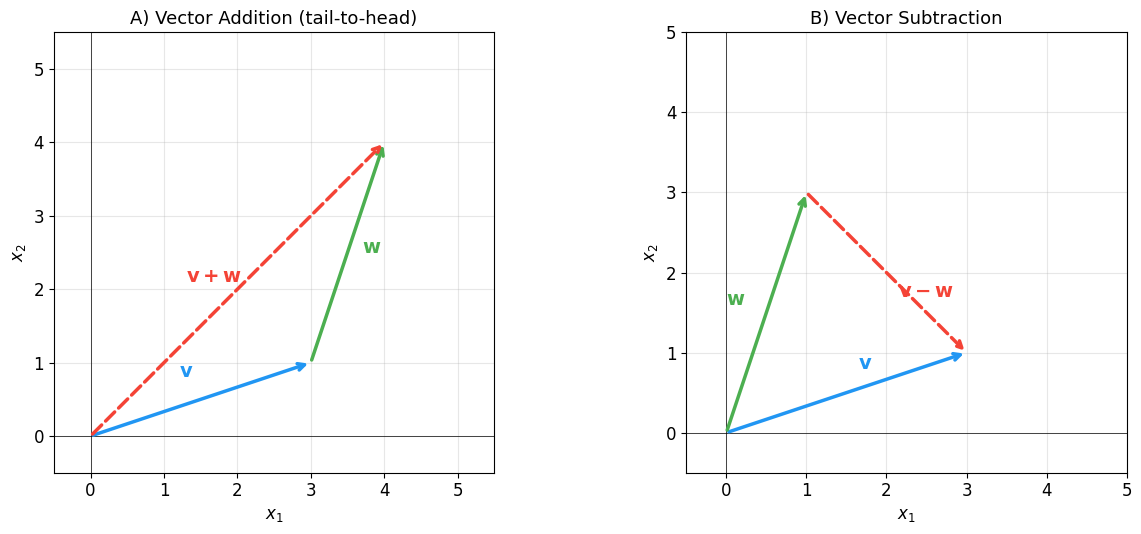

Figure saved.


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

v = np.array([3, 1])
w = np.array([1, 3])

# --- Panel A: Addition (tail-to-head) ---
ax = axes[0]
# v from origin
ax.annotate('', xy=v, xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='#2196F3', lw=2.5))
ax.text(v[0]/2 - 0.3, v[1]/2 + 0.3, '$\mathbf{v}$', fontsize=14, color='#2196F3')

# w from head of v
ax.annotate('', xy=v+w, xytext=v,
            arrowprops=dict(arrowstyle='->', color='#4CAF50', lw=2.5))
ax.text(v[0] + w[0]/2 + 0.2, v[1] + w[1]/2, '$\mathbf{w}$', fontsize=14, color='#4CAF50')

# sum from origin
ax.annotate('', xy=v+w, xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='#F44336', lw=2.5, ls='--'))
ax.text((v[0]+w[0])/2 - 0.7, (v[1]+w[1])/2 + 0.1,
        '$\mathbf{v+w}$', fontsize=14, color='#F44336')

ax.set_xlim(-0.5, 5.5)
ax.set_ylim(-0.5, 5.5)
ax.set_aspect('equal')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(0, color='k', lw=0.5)
ax.set_title('A) Vector Addition (tail-to-head)', fontsize=13)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')

# --- Panel B: Subtraction ---
ax = axes[1]
# v from origin
ax.annotate('', xy=v, xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='#2196F3', lw=2.5))
ax.text(v[0]/2 + 0.15, v[1]/2 + 0.3, '$\mathbf{v}$', fontsize=14, color='#2196F3')

# w from origin
ax.annotate('', xy=w, xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='#4CAF50', lw=2.5))
ax.text(w[0]/2 - 0.5, w[1]/2 + 0.1, '$\mathbf{w}$', fontsize=14, color='#4CAF50')

# v-w from head of w to head of v
ax.annotate('', xy=v, xytext=w,
            arrowprops=dict(arrowstyle='->', color='#F44336', lw=2.5, ls='--'))
ax.text((v[0]+w[0])/2 + 0.15, (v[1]+w[1])/2 - 0.3,
        '$\mathbf{v-w}$', fontsize=14, color='#F44336')

ax.set_xlim(-0.5, 5)
ax.set_ylim(-0.5, 5)
ax.set_aspect('equal')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(0, color='k', lw=0.5)
ax.set_title('B) Vector Subtraction', fontsize=13)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')

plt.tight_layout()
plt.savefig('fig_add_sub.png', dpi=100, bbox_inches='tight')
plt.show()
print('Figure saved.')

Panel A shows the **tail-to-head** construction: place $\mathbf{w}$ so its tail touches the head of $\mathbf{v}$. The dashed red arrow from the origin to the final head is $\mathbf{v} + \mathbf{w} = [4, 4]^T$. This procedure generalises to summing any number of vectors.

Panel B shows **subtraction**: both vectors start at the origin, and $\mathbf{v} - \mathbf{w} = [2, -2]^T$ is the arrow from the head of $\mathbf{w}$ to the head of $\mathbf{v}$.

**Why subtraction geometry matters:** Orthogonal vector decomposition (Section 7 below) relies entirely on vector subtraction. The residual $\mathbf{b} - \beta\mathbf{a}$ *is* a subtraction vector, and requiring it to be perpendicular to $\mathbf{a}$ is what yields the projection formula. Understanding this picture now pays dividends when we reach least-squares regression in later chapters.

## 3. Vector-Scalar Multiplication

A **scalar** ($\lambda$, $\alpha$, $\sigma$, etc.) is a single number. Multiplying a vector by a scalar scales every element:

$$
\lambda \mathbf{w} = \lambda \begin{bmatrix} w_1 \\ w_2 \\ \vdots \\ w_n \end{bmatrix}
= \begin{bmatrix} \lambda w_1 \\ \lambda w_2 \\ \vdots \\ \lambda w_n \end{bmatrix}
$$

Geometrically, the scalar **scales** the vector's magnitude without changing its direction (unless the scalar is negative, which flips the direction by $180°$). This is why scalars are called "scalars" -- they *scale* things.

In [25]:
# Textbook example
lam = 4
w = np.array([9, 4, 1])
print(f'lambda * w = {lam} * {w} = {lam * w}')

# Beware: list vs array
s = 2
a_list = [3, 4, 5]
b_array = np.array(a_list)

print(f'\nList * scalar:    {a_list} * {s} = {a_list * s}')
print(f'ndarray * scalar: {b_array} * {s} = {b_array * s}')

lambda * w = 4 * [9 4 1] = [36 16  4]

List * scalar:    [3, 4, 5] * 2 = [3, 4, 5, 3, 4, 5]
ndarray * scalar: [3 4 5] * 2 = [ 6  8 10]


The scalar multiplication $4 \times [9, 4, 1]^T = [36, 16, 4]^T$ follows the formula exactly.

The **list vs. array trap** is on full display here. Python's `*` operator is **overloaded**: for a `list`, it means "repeat the list $s$ times" (giving `[3, 4, 5, 3, 4, 5]`), while for a NumPy `ndarray`, it means element-wise multiplication (giving `[6, 8, 10]`). This is a real source of bugs. The textbook rightly highlights this.

**Quick exercise from the text:** What happens if you set `s = 2.0` instead of `s = 2`? Answer: the list multiplication fails (`TypeError`) because Python cannot repeat a list a non-integer number of times, even though `2.0` is mathematically an integer. The array multiplication works identically. This reinforces: always use `np.array` for linear algebra.

### 3.1 Scalar-Vector Addition

Formally undefined in linear algebra (you cannot add different types of objects), but Python handles it via broadcasting -- the scalar is added to **every** element:

In [26]:
s = 2
v = np.array([3, 6])
print(f's + v = {s} + {v} = {s + v}')

s + v = 2 + [3 6] = [5 8]


The result $[5, 8]$ shows each element increased by $2$. Mathematically, this is equivalent to adding the vector $\mathbf{s} \cdot \mathbf{1}$ (a vector of all $s$'s), but the shorthand is convenient for coding.

### 3.2 Geometry of Scalar Multiplication

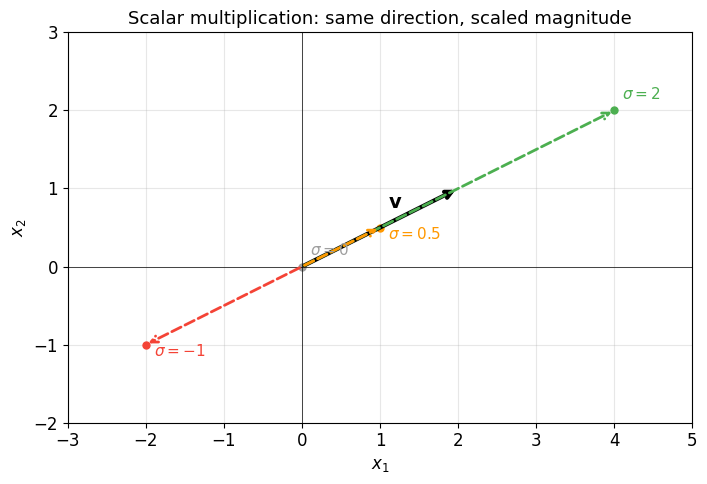

Figure saved.


In [27]:
fig, ax = plt.subplots(figsize=(8, 5))

v = np.array([2, 1])
scalars = [2, 0.5, 0, -1]
colors = ['#4CAF50', '#FF9800', '#9E9E9E', '#F44336']
offsets = [0.15, -0.15, 0.15, -0.15]  # vertical offset for label visibility

# Original vector
ax.annotate('', xy=v, xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='k', lw=3))
ax.text(v[0]/2 + 0.1, v[1]/2 + 0.25, '$\mathbf{v}$', fontsize=14, fontweight='bold')

for sigma, c, off in zip(scalars, colors, offsets):
    sv = sigma * v
    if sigma != 0:
        ax.annotate('', xy=sv, xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color=c, lw=2, ls='--'))
    ax.text(sv[0] + 0.1, sv[1] + off,
            f'$\\sigma={sigma}$', fontsize=11, color=c)
    ax.plot(*sv, 'o', color=c, ms=5)

ax.set_xlim(-3, 5)
ax.set_ylim(-2, 3)
ax.set_aspect('equal')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(0, color='k', lw=0.5)
ax.set_title('Scalar multiplication: same direction, scaled magnitude', fontsize=13)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
plt.tight_layout()
plt.savefig('fig_scalar_mult.png', dpi=100, bbox_inches='tight')
plt.show()
print('Figure saved.')

Four cases of scalar multiplication are visible:

| Scalar $\sigma$ | Effect on $\mathbf{v}$ |
|:---:|:---|
| $\sigma > 1$ | Stretches the vector (longer, same direction) |
| $0 < \sigma < 1$ | Shrinks the vector (shorter, same direction) |
| $\sigma = 0$ | Collapses the vector to the **zeros vector** $\mathbf{0}$ |
| $\sigma < 0$ | Reverses direction and scales magnitude |

Although the negative scalar "flips" the vector, in the context of **subspaces** (Chapter 3+), both $\mathbf{v}$ and $-\mathbf{v}$ lie on the same infinite line through the origin. So in that deeper sense, the direction is preserved. This interpretation becomes essential when we study **eigenvectors** and **singular vectors** later in the book.

### 3.3 The Zeros Vector

The **zeros vector** $\mathbf{0}$ is a vector of all zeros. It is special: multiplying any vector by $\sigma = 0$ produces it, and it is the additive identity ($\mathbf{v} + \mathbf{0} = \mathbf{v}$). Solving a linear system with $\mathbf{x} = \mathbf{0}$ is called the **trivial solution** and is usually excluded. Much of linear algebra is about finding *nontrivial* solutions.

In [28]:
zeros_vec = np.zeros(5)
print(f'Zeros vector: {zeros_vec}')
print(f'Any vector + 0 = itself: {np.array([1,2,3,4,5]) + np.zeros(5)}')
print(f'Norm of zeros vector: {np.linalg.norm(zeros_vec)}')

Zeros vector: [0. 0. 0. 0. 0.]
Any vector + 0 = itself: [1. 2. 3. 4. 5.]
Norm of zeros vector: 0.0


The zeros vector has norm $\|\mathbf{0}\| = 0$, confirming it is the only vector with zero magnitude. It is also the only vector for which a **unit vector** cannot be defined (you cannot divide by zero norm). We will return to this point in Section 4.

## 4. The Transpose Operation

The **transpose** swaps rows and columns:

$$
m_{i,j}^T = m_{j,i}
$$

For vectors, this means a column vector becomes a row vector and vice versa. A fundamental identity:

$$
(\mathbf{v}^T)^T = \mathbf{v}
$$

Transposing twice returns to the original. This seemingly trivial fact is the keystone of proofs involving symmetric matrices (e.g., covariance matrices $\mathbf{X}^T\mathbf{X}$) and is the reason PCA produces orthogonal rotations.

In [29]:
v = np.array([[1, 2, 3, 4]])  # row: (1, 4)
print(f'v shape:      {v.shape}  ->  {v}')
print(f'v^T shape:    {v.T.shape}  ->  {v.T.flatten()}')
print(f'v^T^T shape:  {v.T.T.shape}  ->  {v.T.T}')
print(f'\nv == v^T^T?  {np.array_equal(v, v.T.T)}')

v shape:      (1, 4)  ->  [[1 2 3 4]]
v^T shape:    (4, 1)  ->  [1 2 3 4]
v^T^T shape:  (1, 4)  ->  [[1 2 3 4]]

v == v^T^T?  True


The row vector $(1, 4)$ becomes a column $(4, 1)$ after one transpose, and returns to $(1, 4)$ after a second. The identity $(\mathbf{v}^T)^T = \mathbf{v}$ holds exactly, as confirmed by `np.array_equal`.

**Note on 1D arrays:** If `v` were a 1D array of shape `(4,)`, then `v.T` would still be `(4,)` -- the transpose has no effect on 1D arrays. This is another reason to be explicit about 2D shapes in production code.

## 5. Vector Broadcasting in Python

**Broadcasting** is a NumPy mechanism (not a traditional linear algebra concept) that automatically expands dimensions to make operations compatible. It repeats one operand along its singleton dimensions to match the other operand.

In [30]:
v = np.array([[1, 2, 3]]).T   # column (3, 1)
w = np.array([[10, 20]])       # row (1, 2)

print(f'v shape: {v.shape}')
print(f'w shape: {w.shape}')
print(f'\nv + w (broadcast):')
print(v + w)

v shape: (3, 1)
w shape: (1, 2)

v + w (broadcast):
[[11 21]
 [12 22]
 [13 23]]


Broadcasting stretched the $(3, 1)$ column across 2 columns and the $(1, 2)$ row down 3 rows, producing a $(3, 2)$ matrix:

$$
\begin{bmatrix} 1 \\ 2 \\ 3 \end{bmatrix}
+
\begin{bmatrix} 10 & 20 \end{bmatrix}
=
\begin{bmatrix}
1+10 & 1+20 \\
2+10 & 2+20 \\
3+10 & 3+20
\end{bmatrix}
=
\begin{bmatrix}
11 & 21 \\
12 & 22 \\
13 & 23
\end{bmatrix}
$$

The textbook's original example (with `[10, 20]` and `[1, 2, 3]`) produces exactly this. Broadcasting is heavily used in vectorised computations -- for example, **k-means clustering** (Chapter 4) computes distances between every data point and every centroid via a single broadcasted subtraction.

## 6. Vector Magnitude and Unit Vectors

### 6.1 The Norm (Magnitude)

The **magnitude** (also called the **norm** or **geometric length**) of a vector is the Euclidean distance from tail to head:

$$
\|\mathbf{v}\| = \sqrt{\sum_{i=1}^{n} v_i^2}
$$

This is the standard $\ell_2$ norm. In Python, **`len(v)`** returns the *dimensionality* (number of elements), while **`np.linalg.norm(v)`** returns the *magnitude*.

In [31]:
v = np.array([1, 2, 3, 7, 8, 9])

v_dim = len(v)
v_mag = np.linalg.norm(v)

# Manual verification
v_mag_manual = np.sqrt(np.sum(v**2))

print(f'Vector v:        {v}')
print(f'Dimensionality:  {v_dim}')
print(f'Magnitude:       {v_mag:.6f}')
print(f'Manual check:    {v_mag_manual:.6f}')
print(f'Squared magnitude: {np.sum(v**2)}')

Vector v:        [1 2 3 7 8 9]
Dimensionality:  6
Magnitude:       14.422205
Manual check:    14.422205
Squared magnitude: 208


The vector $\mathbf{v} = [1, 2, 3, 7, 8, 9]^T$ has **dimensionality** $n = 6$ and **magnitude**:

$$
\|\mathbf{v}\| = \sqrt{1^2 + 2^2 + 3^2 + 7^2 + 8^2 + 9^2} = \sqrt{1 + 4 + 9 + 49 + 64 + 81} = \sqrt{208} \approx 14.4222
$$

Both `np.linalg.norm` and the manual calculation agree. The **squared magnitude** $\|\mathbf{v}\|^2 = 208$ is frequently used in practice (e.g., in loss functions) because it avoids the square root, which is computationally cheaper and avoids numerical issues near zero.

### 6.2 Unit Vectors

A **unit vector** has magnitude exactly 1: $\|\hat{\mathbf{v}}\| = 1$. Any nonzero vector $\mathbf{v}$ has an associated unit vector:

$$
\hat{\mathbf{v}} = \frac{1}{\|\mathbf{v}\|} \mathbf{v}
$$

The hat notation $\hat{\mathbf{v}}$ indicates a unit vector in the same direction as $\mathbf{v}$. The **only** nonzero-norm vector without an associated unit vector is... well, there is none -- but the **zeros vector** $\mathbf{0}$ has $\|\mathbf{0}\| = 0$, and dividing by zero is undefined, so the zeros vector has no unit vector.

In [32]:
v = np.array([3, 4])  # classic 3-4-5 right triangle
v_mag = np.linalg.norm(v)
v_hat = v / v_mag

print(f'v       = {v}')
print(f'||v||   = {v_mag}')
print(f'v_hat   = {v_hat}')
print(f'||v_hat|| = {np.linalg.norm(v_hat)}')

v       = [3 4]
||v||   = 5.0
v_hat   = [0.6 0.8]
||v_hat|| = 1.0


We chose the classic $[3, 4]^T$ vector with $\|\mathbf{v}\| = \sqrt{9 + 16} = 5$. The unit vector is:

$$
\hat{\mathbf{v}} = \frac{1}{5} \begin{bmatrix} 3 \\ 4 \end{bmatrix} = \begin{bmatrix} 0.6 \\ 0.8 \end{bmatrix}
$$

Verification: $\|\hat{\mathbf{v}}\| = \sqrt{0.6^2 + 0.8^2} = \sqrt{0.36 + 0.64} = \sqrt{1} = 1$. The direction is preserved but the magnitude is exactly 1.

**Where unit vectors appear in practice:** Orthogonal matrices, rotation matrices, eigenvectors, and singular vectors are all defined using unit vectors. In NLP, normalising word embeddings to unit length converts dot products into **cosine similarity**, which is the standard similarity metric for text.

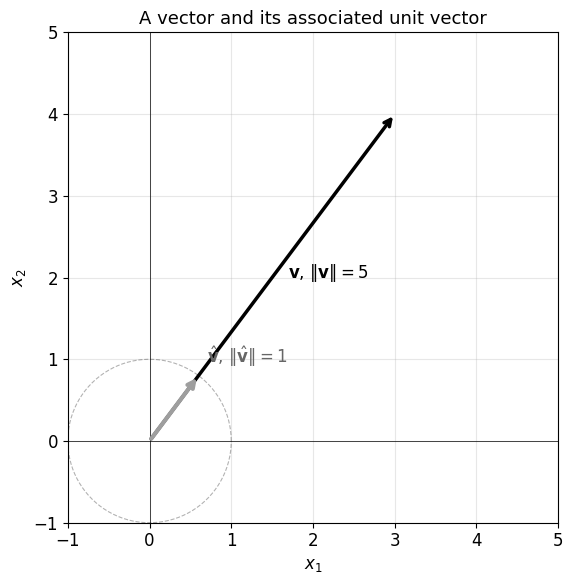

Figure saved.


In [33]:
# Visualize vector and its unit vector
fig, ax = plt.subplots(figsize=(6, 6))

v = np.array([3, 4])
v_hat = v / np.linalg.norm(v)

# Original vector
ax.annotate('', xy=v, xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='k', lw=2.5))
ax.text(v[0]/2 + 0.2, v[1]/2, f'$\\mathbf{{v}}$, $\\|\\mathbf{{v}}\\|={np.linalg.norm(v):.0f}$',
        fontsize=12)

# Unit vector (thicker, different color)
ax.annotate('', xy=v_hat, xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='#9E9E9E', lw=3))
ax.text(v_hat[0] + 0.1, v_hat[1] + 0.15,
        f'$\\hat{{\\mathbf{{v}}}}$, $\\|\\hat{{\\mathbf{{v}}}}\\|=1$',
        fontsize=12, color='#666')

# Unit circle for reference
theta = np.linspace(0, 2*np.pi, 100)
ax.plot(np.cos(theta), np.sin(theta), 'k--', lw=0.8, alpha=0.3)

ax.set_xlim(-1, 5)
ax.set_ylim(-1, 5)
ax.set_aspect('equal')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(0, color='k', lw=0.5)
ax.set_title('A vector and its associated unit vector', fontsize=13)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
plt.tight_layout()
plt.savefig('fig_unit_vec.png', dpi=100, bbox_inches='tight')
plt.show()
print('Figure saved.')

The gray unit vector $\hat{\mathbf{v}}$ lies on the unit circle (dashed), confirming its magnitude is exactly 1. It points in the same direction as the black vector $\mathbf{v}$ but has been rescaled. The unit circle is the set of all possible unit vectors in $\mathbb{R}^2$.

## 7. The Dot Product

The **dot product** (also called the **inner product**) is arguably the single most important operation in linear algebra. It is the computational atom from which convolution, correlation, the Fourier transform, matrix multiplication, and countless ML algorithms are built.

### 7.1 Algebraic Definition

The dot product is **element-wise multiply, then sum**:

$$
\delta = \mathbf{a}^T \mathbf{b} = \sum_{i=1}^{n} a_i b_i
$$

Both vectors must have the same dimensionality. The result is a **scalar**, not a vector.

In [34]:
v = np.array([1, 2, 3, 4])
w = np.array([5, 6, 7, 8])

dot_result = np.dot(v, w)

# Step-by-step verification
products = v * w  # element-wise
manual_sum = np.sum(products)

print(f'v = {v}')
print(f'w = {w}')
print(f'Element-wise products: {products}')
print(f'Sum of products:       {manual_sum}')
print(f'np.dot(v, w):          {dot_result}')

v = [1 2 3 4]
w = [5 6 7 8]
Element-wise products: [ 5 12 21 32]
Sum of products:       70
np.dot(v, w):          70


Step by step:

$$
\mathbf{v}^T \mathbf{w} = 1 \times 5 + 2 \times 6 + 3 \times 7 + 4 \times 8
= 5 + 12 + 21 + 32 = 70
$$

The element-wise products are $[5, 12, 21, 32]$ and their sum is $70$. Both the manual calculation and `np.dot` agree.

**Interpretation:** The dot product measures the **similarity** or **alignment** between two vectors. When both vectors point in roughly the same direction, the dot product is large and positive. When they are perpendicular, the dot product is zero. When they point in opposite directions, the dot product is large and negative. We will formalise this with the geometric definition below.

**`np.dot()` caveat:** This function actually implements **matrix multiplication**, which generalises to collections of dot products. For 1D arrays, it correctly computes the dot product. For 2D arrays, the result depends on orientation (row vs. column) -- a point the textbook asks you to explore.

### 7.2 Scalar Multiplication Scales the Dot Product

In [35]:
v = np.array([1, 2, 3, 4])
w = np.array([5, 6, 7, 8])

s_pos = 10
s_neg = -1
s_zero = 0

print(f'v . w       = {np.dot(v, w)}')
print(f'(10*v) . w  = {np.dot(s_pos * v, w)}')
print(f'(-1*v) . w  = {np.dot(s_neg * v, w)}')
print(f'(0*v) . w   = {np.dot(s_zero * v, w)}')

v . w       = 70
(10*v) . w  = 700
(-1*v) . w  = -70
(0*v) . w   = 0


The results confirm the **scalar-dot product property**: $\sigma(\mathbf{v}^T \mathbf{w}) = (\sigma\mathbf{v})^T \mathbf{w}$.

- Scaling by $\sigma = 10$ multiplies the dot product: $10 \times 70 = 700$.
- Scaling by $\sigma = -1$ reverses the sign: $-1 \times 70 = -70$.
- Scaling by $\sigma = 0$ annihilates the dot product: $0 \times 70 = 0$.

This property is linear in the scalar, which is part of why the dot product (and by extension, matrix multiplication) is a **linear** operation.

### 7.3 The Dot Product Is Distributive

The distributive property:

$$
\mathbf{a}^T(\mathbf{b} + \mathbf{c}) = \mathbf{a}^T\mathbf{b} + \mathbf{a}^T\mathbf{c}
$$

In words: the dot product of a sum equals the sum of the dot products.

In [36]:
a = np.array([0, 1, 2])
b = np.array([3, 5, 8])
c = np.array([13, 21, 34])

res1 = np.dot(a, b + c)
res2 = np.dot(a, b) + np.dot(a, c)

print(f'a . (b + c)     = {res1}')
print(f'a.b + a.c       = {res2}')
print(f'Equal?           {res1 == res2}')

a . (b + c)     = 110
a.b + a.c       = 110
Equal?           True


Both sides yield $110$, confirming distributivity. Let's verify manually:

$$
\mathbf{a}^T(\mathbf{b} + \mathbf{c}) = [0, 1, 2] \cdot [16, 26, 42] = 0 + 26 + 84 = 110
$$
$$
\mathbf{a}^T\mathbf{b} + \mathbf{a}^T\mathbf{c} = (0 + 5 + 16) + (0 + 21 + 68) = 21 + 89 = 110
$$

The distributive property is heavily used in deriving the orthogonal projection formula (Section 9) and in proving properties of matrix multiplication. It is also the algebraic backbone of the gradient computation for linear models: $\nabla_\mathbf{w} \mathbf{w}^T\mathbf{X}^T\mathbf{y}$ uses distributivity at every step.

### 7.4 Geometric Definition of the Dot Product

The dot product can also be expressed as:

$$
\mathbf{v}^T \mathbf{w} = \|\mathbf{v}\| \, \|\mathbf{w}\| \, \cos(\theta_{\mathbf{v}, \mathbf{w}})
$$

where $\theta_{\mathbf{v}, \mathbf{w}}$ is the angle between the two vectors. This formula is equivalent to the algebraic definition (proven via the Law of Cosines). The key insight:

- Magnitudes $\|\mathbf{v}\|$ and $\|\mathbf{w}\|$ are always $\geq 0$
- $\cos\theta$ ranges from $-1$ to $+1$
- Therefore, the **sign** of the dot product is determined entirely by the angle between the vectors

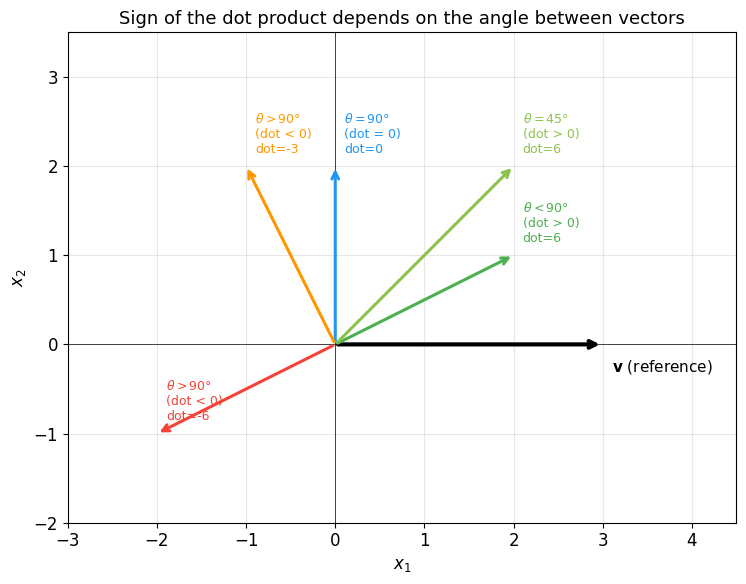

Figure saved.


In [37]:
fig, ax = plt.subplots(figsize=(9, 6))

# Define five cases
ref = np.array([3, 0])  # reference vector along x-axis
cases = [
    (np.array([2, 1]),    '$\\theta < 90°$\n(dot > 0)'),
    (np.array([2, 2]),    '$\\theta = 45°$\n(dot > 0)'),
    (np.array([0, 2]),    '$\\theta = 90°$\n(dot = 0)'),
    (np.array([-1, 2]),   '$\\theta > 90°$\n(dot < 0)'),
    (np.array([-2, -1]),  '$\\theta > 90°$\n(dot < 0)'),
]
colors = ['#4CAF50', '#8BC34A', '#2196F3', '#FF9800', '#F44336']

# Draw reference vector
ax.annotate('', xy=ref, xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='k', lw=3))
ax.text(ref[0] + 0.1, ref[1] - 0.3, '$\mathbf{v}$ (reference)', fontsize=11)

for (w, label), c in zip(cases, colors):
    dp = np.dot(ref, w)
    ax.annotate('', xy=w, xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=c, lw=2.2))
    ax.text(w[0] + 0.1, w[1] + 0.15, f'{label}\ndot={dp}', fontsize=9, color=c)

ax.set_xlim(-3, 4.5)
ax.set_ylim(-2, 3.5)
ax.set_aspect('equal')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(0, color='k', lw=0.5)
ax.set_title('Sign of the dot product depends on the angle between vectors', fontsize=13)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
plt.tight_layout()
plt.savefig('fig_dot_geometry.png', dpi=100, bbox_inches='tight')
plt.show()
print('Figure saved.')

The figure illustrates the geometric interpretation:

| Angle $\theta$ | $\cos\theta$ | Dot product sign | Meaning |
|:-:|:-:|:-:|:---|
| $0° < \theta < 90°$ | Positive | Positive | Vectors point in "similar" directions |
| $\theta = 90°$ | Zero | **Zero** | Vectors are **orthogonal** (perpendicular) |
| $90° < \theta \leq 180°$ | Negative | Negative | Vectors point in "opposite" directions |

**Commit this to memory:** Orthogonal vectors have a dot product of zero. This equivalence ($\mathbf{a}^T \mathbf{b} = 0 \iff \mathbf{a} \perp \mathbf{b}$) is used everywhere: Gram-Schmidt orthogonalization, QR decomposition, orthogonal projections, PCA, and the condition for uncorrelated features.

Dividing the dot product by the product of magnitudes isolates $\cos\theta$, which gives the **cosine similarity**:

$$
\cos(\theta) = \frac{\mathbf{v}^T \mathbf{w}}{\|\mathbf{v}\| \, \|\mathbf{w}\|}
$$

This normalised version removes the influence of vector magnitudes and measures pure directional alignment -- which is exactly what makes it the go-to similarity metric in NLP and recommendation systems.

## 8. Other Vector Multiplications

### 8.1 Hadamard (Element-wise) Multiplication

The **Hadamard product** $\odot$ multiplies corresponding elements, producing a vector of the same dimensionality:

$$
\mathbf{a} \odot \mathbf{b} = \begin{bmatrix} a_1 b_1 \\ a_2 b_2 \\ \vdots \\ a_n b_n \end{bmatrix}
$$

Unlike the dot product (which produces a scalar), the Hadamard product produces a **vector**.

In [38]:
a = np.array([5, 4, 8, 2])
b = np.array([1, 0, 0.5, -1])

hadamard = a * b
print(f'a = {a}')
print(f'b = {b}')
print(f'a * b (Hadamard) = {hadamard}')

# Connection to dot product: dot product = sum of Hadamard product
print(f'\nsum(a * b) = {np.sum(hadamard)}')
print(f'np.dot(a, b) = {np.dot(a, b)}')

a = [5 4 8 2]
b = [ 1.   0.   0.5 -1. ]
a * b (Hadamard) = [ 5.  0.  4. -2.]

sum(a * b) = 7.0
np.dot(a, b) = 7.0


The Hadamard product is $[5, 0, 4, -2]$, exactly as the textbook shows. Notice the relationship: the **dot product is the sum of the Hadamard product**. Both yield $7.0$.

$$
\mathbf{a}^T \mathbf{b} = \sum_i (\mathbf{a} \odot \mathbf{b})_i = 5 + 0 + 4 + (-2) = 7
$$

**Practical example from the text:** Suppose $\mathbf{a}$ encodes units sold per shop and $\mathbf{b}$ encodes price per unit. Then $\mathbf{a} \odot \mathbf{b}$ gives revenue *per shop* (a vector), while $\mathbf{a}^T\mathbf{b}$ gives *total* revenue (a scalar). Both come from the same element-wise products.

**Bug alert from the text:** The textbook shows `a = np.array([5,4,8,2])` and `b = np.array([1,0,.5])` -- but `b` has only 3 elements while `a` has 4. Running this raises a `ValueError` because Hadamard multiplication requires **equal dimensionality**, just like vector addition.

### 8.2 The Outer Product

The **outer product** of a column vector $\mathbf{v} \in \mathbb{R}^m$ and a row vector $\mathbf{w}^T \in \mathbb{R}^n$ produces an $m \times n$ matrix:

$$
\mathbf{v} \mathbf{w}^T = \begin{bmatrix} v_1 \\ v_2 \\ v_3 \end{bmatrix}
\begin{bmatrix} w_1 & w_2 \end{bmatrix}
= \begin{bmatrix}
v_1 w_1 & v_1 w_2 \\
v_2 w_1 & v_2 w_2 \\
v_3 w_1 & v_3 w_2
\end{bmatrix}
$$

Key differences from the dot product:

| Property | Dot product $\mathbf{v}^T\mathbf{w}$ | Outer product $\mathbf{v}\mathbf{w}^T$ |
|----------|:-:|:-:|
| Result type | Scalar | Matrix |
| Requires same dim? | Yes | No |
| Notation | $\mathbf{v}^T\mathbf{w}$ (row $\times$ column) | $\mathbf{v}\mathbf{w}^T$ (column $\times$ row) |

In [39]:
v = np.array([1, 2, 3])
w = np.array([4, 5])

outer = np.outer(v, w)
print(f'v = {v}  (dim {len(v)})')
print(f'w = {w}  (dim {len(w)})')
print(f'\nOuter product (v w^T):')
print(outer)
print(f'Shape: {outer.shape}')

v = [1 2 3]  (dim 3)
w = [4 5]  (dim 2)

Outer product (v w^T):
[[ 4  5]
 [ 8 10]
 [12 15]]
Shape: (3, 2)


The outer product of $\mathbf{v} \in \mathbb{R}^3$ and $\mathbf{w} \in \mathbb{R}^2$ is a $(3 \times 2)$ matrix. Each row is $\mathbf{w}$ scaled by the corresponding element of $\mathbf{v}$:

$$
\begin{bmatrix} 1 \\ 2 \\ 3 \end{bmatrix}
\begin{bmatrix} 4 & 5 \end{bmatrix}
= \begin{bmatrix} 4 & 5 \\ 8 & 10 \\ 12 & 15 \end{bmatrix}
$$

This produces what later chapters will call a **rank-1 matrix** -- every row is a scalar multiple of every other row. The outer product is the fundamental building block of the **singular value decomposition (SVD)**, where any matrix is decomposed into a sum of rank-1 outer products.

**Note on notation:** $\mathbf{v}^T\mathbf{w}$ (dot product) has the transpose on the *first* vector; $\mathbf{v}\mathbf{w}^T$ (outer product) has it on the *second*. This distinction will become completely clear after Chapter 5 on matrix multiplication.

## 9. Orthogonal Vector Decomposition

**Decomposing** a mathematical object means breaking it into simpler pieces. Just as $42 = 2 \times 3 \times 7$ (prime factorization), we can decompose vectors into meaningful components. Much of applied linear algebra is about matrix decompositions.

### 9.1 The Projection Problem

Given two vectors $\mathbf{a}$ and $\mathbf{b}$, we want to find the point on $\mathbf{a}$ that is **closest** to the head of $\mathbf{b}$. That closest point is $\beta\mathbf{a}$ for some scalar $\beta$.

The key geometric insight: the closest point is found by dropping a perpendicular from $\mathbf{b}$ onto $\mathbf{a}$. This means $\mathbf{b} - \beta\mathbf{a}$ must be **orthogonal** to $\mathbf{a}$:

$$
\mathbf{a}^T(\mathbf{b} - \beta\mathbf{a}) = 0
$$

Applying the distributive property and solving for $\beta$:

$$
\mathbf{a}^T\mathbf{b} - \beta\,\mathbf{a}^T\mathbf{a} = 0
\quad \Longrightarrow \quad
\beta = \frac{\mathbf{a}^T\mathbf{b}}{\mathbf{a}^T\mathbf{a}}
$$

This is the **orthogonal projection** formula. The numerator $\mathbf{a}^T\mathbf{b}$ is sometimes called the "mapping" (how much of $\mathbf{b}$ aligns with $\mathbf{a}$), and the denominator $\mathbf{a}^T\mathbf{a}$ is the "magnitude" ($= \|\mathbf{a}\|^2$). Hence the mnemonic: **mapping over magnitude**.

### 9.2 The Decomposition

Once we have $\beta$, we decompose the **target vector** $\mathbf{t}$ into two components relative to the **reference vector** $\mathbf{r}$:

$$
\underbrace{\mathbf{t}_{\|\mathbf{r}}}_{\text{parallel component}} = \frac{\mathbf{r}^T\mathbf{t}}{\mathbf{r}^T\mathbf{r}}\,\mathbf{r}
\qquad\qquad
\underbrace{\mathbf{t}_{\perp\mathbf{r}}}_{\text{perpendicular component}} = \mathbf{t} - \mathbf{t}_{\|\mathbf{r}}
$$

These satisfy two properties: (1) $\mathbf{t}_{\|\mathbf{r}} + \mathbf{t}_{\perp\mathbf{r}} = \mathbf{t}$, and (2) $\mathbf{t}_{\perp\mathbf{r}}^T \mathbf{r} = 0$.

In [40]:
# Target and reference vectors
t = np.array([4, 1])   # target
r = np.array([2, 3])   # reference

# Projection scalar beta = (r . t) / (r . r)
beta = np.dot(r, t) / np.dot(r, r)

# Parallel component
t_parallel = beta * r

# Perpendicular component
t_perp = t - t_parallel

print(f'Target t = {t}')
print(f'Reference r = {r}')
print(f'\nbeta = r.t / r.r = {np.dot(r, t)} / {np.dot(r, r)} = {beta:.4f}')
print(f'\nParallel component t_par  = {t_parallel}')
print(f'Perpendicular component t_perp = {t_perp}')
print(f'\nVerification:')
print(f'  t_par + t_perp = {t_parallel + t_perp}  (should equal t = {t})')
print(f'  t_perp . r     = {np.dot(t_perp, r):.10f}  (should be 0)')

Target t = [4 1]
Reference r = [2 3]

beta = r.t / r.r = 11 / 13 = 0.8462

Parallel component t_par  = [1.69230769 2.53846154]
Perpendicular component t_perp = [ 2.30769231 -1.53846154]

Verification:
  t_par + t_perp = [4. 1.]  (should equal t = [4 1])
  t_perp . r     = 0.0000000000  (should be 0)


The decomposition produces:

$$
\beta = \frac{\mathbf{r}^T\mathbf{t}}{\mathbf{r}^T\mathbf{r}} = \frac{2 \times 4 + 3 \times 1}{2^2 + 3^2} = \frac{11}{13} \approx 0.8462
$$

$$
\mathbf{t}_{\|\mathbf{r}} = 0.8462 \times [2, 3]^T = [1.6923, 2.5385]^T
$$

$$
\mathbf{t}_{\perp\mathbf{r}} = [4, 1]^T - [1.6923, 2.5385]^T = [2.3077, -1.5385]^T
$$

Both verification checks pass: the components sum back to $\mathbf{t}$, and the perpendicular component has a dot product of $0$ with $\mathbf{r}$ (to numerical precision), confirming true orthogonality.

**Why this matters enormously:** This formula is the seed of **least squares regression**. In a linear model $\mathbf{y} \approx \mathbf{X}\mathbf{w}$, we project $\mathbf{y}$ onto the column space of $\mathbf{X}$, and the residual $\mathbf{y} - \mathbf{X}\mathbf{w}$ is orthogonal to that space -- the exact same idea, scaled up to matrices. The Gram-Schmidt procedure and QR decomposition (later chapters) apply this formula iteratively to build orthogonal bases.

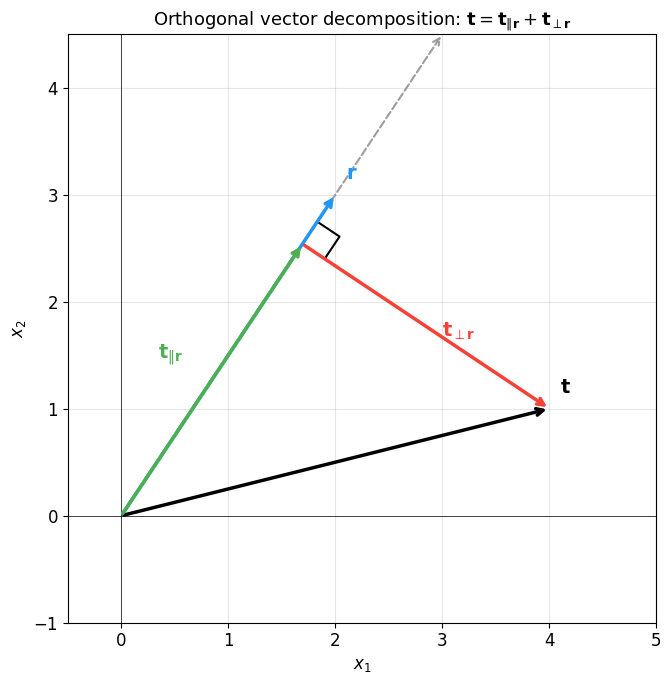

Figure saved.


In [41]:
fig, ax = plt.subplots(figsize=(7, 7))

t = np.array([4, 1])
r = np.array([2, 3])
beta = np.dot(r, t) / np.dot(r, r)
t_par = beta * r
t_perp = t - t_par

# Reference vector (extended for visual context)
r_ext = 1.5 * r
ax.annotate('', xy=r_ext, xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='#9E9E9E', lw=1.5, ls='--'))
ax.annotate('', xy=r, xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='#2196F3', lw=2.5))
ax.text(r[0] + 0.1, r[1] + 0.15, '$\mathbf{r}$', fontsize=14, color='#2196F3')

# Target vector
ax.annotate('', xy=t, xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='k', lw=2.5))
ax.text(t[0] + 0.1, t[1] + 0.15, '$\mathbf{t}$', fontsize=14, fontweight='bold')

# Parallel component
ax.annotate('', xy=t_par, xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='#4CAF50', lw=2.5))
ax.text(t_par[0]/2 - 0.5, t_par[1]/2 + 0.2,
        '$\mathbf{t}_{\\|\\mathbf{r}}$', fontsize=14, color='#4CAF50')

# Perpendicular component (from t_par to t)
ax.annotate('', xy=t, xytext=t_par,
            arrowprops=dict(arrowstyle='->', color='#F44336', lw=2.5))
ax.text((t_par[0] + t[0])/2 + 0.15, (t_par[1] + t[1])/2 - 0.1,
        '$\mathbf{t}_{\\perp\\mathbf{r}}$', fontsize=14, color='#F44336')

# Right angle indicator
right_angle_size = 0.25
# Direction along r (unit)
r_unit = r / np.linalg.norm(r)
perp_unit = t_perp / np.linalg.norm(t_perp)
corner = t_par
p1 = corner + right_angle_size * perp_unit
p2 = p1 + right_angle_size * r_unit
p3 = corner + right_angle_size * r_unit
ax.plot([p1[0], p2[0], p3[0]], [p1[1], p2[1], p3[1]], 'k-', lw=1.5)

ax.set_xlim(-0.5, 5)
ax.set_ylim(-1, 4.5)
ax.set_aspect('equal')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(0, color='k', lw=0.5)
ax.set_title('Orthogonal vector decomposition: $\mathbf{t} = \mathbf{t}_{\\|\\mathbf{r}} + \mathbf{t}_{\\perp\\mathbf{r}}$',
             fontsize=13)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
plt.tight_layout()
plt.savefig('fig_ortho_decomp.png', dpi=100, bbox_inches='tight')
plt.show()
print('Figure saved.')

The figure shows the orthogonal decomposition in action. The target vector $\mathbf{t}$ (black) is decomposed into:

- **Green arrow:** $\mathbf{t}_{\|\mathbf{r}}$ -- the component *parallel* to $\mathbf{r}$. This is $\beta \mathbf{r}$, the "shadow" of $\mathbf{t}$ onto the line defined by $\mathbf{r}$.
- **Red arrow:** $\mathbf{t}_{\perp\mathbf{r}}$ -- the component *perpendicular* to $\mathbf{r}$. This is the residual.

The small square at the junction confirms the right angle. Together, the green and red arrows reconstruct the original black arrow: $\mathbf{t}_{\|\mathbf{r}} + \mathbf{t}_{\perp\mathbf{r}} = \mathbf{t}$.

**Connection to regression:** In a simple linear regression $y = \beta x + \epsilon$, the fitted values $\hat{y} = \beta x$ are the parallel component and the residuals $\epsilon = y - \hat{y}$ are the perpendicular component. The condition $\mathbf{X}^T \boldsymbol{\epsilon} = 0$ (orthogonality of residuals to predictors) is exactly the same $\mathbf{r}^T \mathbf{t}_{\perp\mathbf{r}} = 0$ condition we verified above.

## Chapter Summary

This chapter established the foundational vocabulary and operations of linear algebra:

**Vectors** are ordered lists of numbers with a dimensionality (number of elements, $n$) and orientation (column or row). In NumPy, orientation is determined by the shape: `(n,)` is orientationless, `(1, n)` is a row, `(n, 1)` is a column.

**Element-wise operations** (addition, subtraction, Hadamard multiplication) require matching dimensionality and orientation. Python's broadcasting can silently "fix" mismatches, sometimes producing unexpected results.

**The dot product** $\mathbf{a}^T\mathbf{b} = \sum_i a_i b_i$ is the fundamental operation of linear algebra. Geometrically, it equals $\|\mathbf{a}\|\,\|\mathbf{b}\|\cos\theta$, making it a measure of alignment. Orthogonal vectors have a dot product of zero.

**Orthogonal vector decomposition** breaks a target vector into parallel and perpendicular components relative to a reference vector, using the projection formula $\beta = \mathbf{a}^T\mathbf{b} \,/\, \mathbf{a}^T\mathbf{a}$ ("mapping over magnitude"). This is the seed of least squares, QR decomposition, and much of applied linear algebra.

These building blocks recur throughout the book. The dot product underlies matrix multiplication (Chapter 5), the projection formula extends to subspaces (Chapter 9), and the principle of orthogonality drives PCA, SVD, and regression.